# **Portfolio Example-Supervised Learning Models to Predict Email Spam**



## Rob Boswell

---
---

### In this portfolio example, I analyze and use features from the following email spam dataset located on the UCI Machine Learning Repository in order to classify emails as either spam or non-spam:
https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/

$~$

### Descriptions of the features used are found at:
https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names



### **Part 1.**  Import the spam dataset and print the first 5 rows.  


---



---


In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import seaborn as sns


In [ ]:
#Please note that the spam_dataset.csv file that I import can be found at: "https://github.com/roboswell/data/blob/main/spam_dataset.csv"
#The spam_dataset.csv file in my "data" Github repository was reconstructed from the original dataset (https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data) 
#to include all 57 feature names and target name 'spam'.

df = pd.read_csv("spam_dataset.csv")

In [ ]:
df.head()

,word_freq_make:,word_freq_address:,word_freq_all:,word_freq_3d:,word_freq_our:,word_freq_over:,word_freq_remove:,word_freq_internet:,word_freq_order:,word_freq_mail:,...,char_freq_;:,char_freq_(:,char_freq_[:,char_freq_!:,char_freq_$:,char_freq_#:,capital_run_length_average:,capital_run_length_longest:,capital_run_length_total:,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### **Part 2.** 

### The dependent variable is "spam" where one indicates that an email is spam and zero otherwise. 

### **Below, I discuss three variables in the dataset that I think would be important predictors in a model of spam, and why:**

---

---


### I think that word_freq_receive, word_freq_free, and word_freq_money are the variables in the dataset likely to be the most important predictors of spam. 

$~$

### **1)** For the feature ***word_freq_free***, the more often a single email contains the word "free" it is likely to be the case that businesses, organizations, or individuals are sending such emails to lure the recipient into believing that they will receive free items by responding to the email. People naturally like free things, and so it is a very common marketing or scam strategy to promise cast a broad net in advertisements promising "free" items to those who respond. As a result, I think that a spam filtering program would be very likley to try to search for this variable. 

$~$

### **2)** Since the feature ***capital_run_length_total*** is defined as the "sum of length of uninterrupted sequences of capital letters" in an email, it seems reasonable to me that the more capitalized words used in an email, the more the sender is trying to get the attention of any given recipient, on average, than the sender would if they only capitalized the beginning of sentences, acronyms, and proper nouns. E.g., writing an entire sentence in capitalized letters is often interpreted as "shouting" at someone by email. Therefore, since more sequential capitalized letters in any given email on average is likely predictive of a given sender's attempt to get a receiver's attention, and thus suggesting that the sender likely believes the recipient normally would not read their email if they did not use capitalized letters so often in words, it would seem that spam filtering programs would definitely try to filter out emails with a lot of words that are capitalized. 

$~$

### **3)** For the feature ***word_freq_money***, the more often a single email references the word "money" it is likely to be the case that businesses, organizations, or individuals are sending such emails to lure the recipient into believing that if they respond to the email they will be able to obtain money. People naturally like money, and so promising money is often a common marketing strategy by companies and scammers to respond. E.g., (trustworthy or untrustworthy) temporary staffing agencies may use the word money in emails to try to attract recipients into responding to apply for jobs that are promised to provide more money that what they have with their current job. As a result, I think that a spam filtering program would be very likley to try to search for this variable.

### **Part 3.**  Here, I visualize the univariate distribution of each of the three variables discussed above.  

Text(0, 0.5, 'Count')

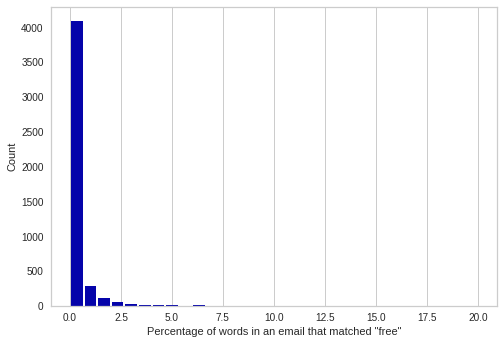

In [ ]:
from matplotlib import pyplot as plt

# 1) Histogram of word_freq_free:
n, bins, patches = plt.hist(x=df['word_freq_free:'], bins=30, color='#0504aa', rwidth=0.85)
plt.grid(axis='y')
plt.xlabel('Percentage of words in an email that matched "free"')
plt.ylabel('Count')


Text(0, 0.5, 'Count')

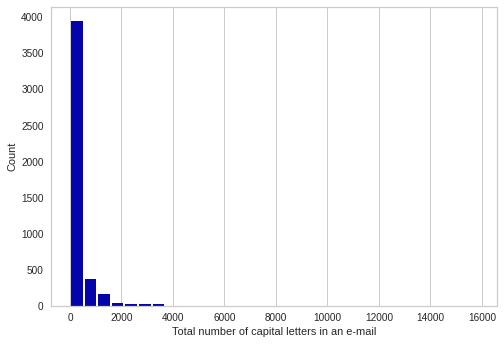

In [ ]:
# 2) Histogram of capital_run_length_total: 
n, bins, patches = plt.hist(x=df['capital_run_length_total:'], bins=30, color='#0504aa', rwidth=0.85)
plt.grid(axis='y')
plt.xlabel('Total number of capital letters in an e-mail')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

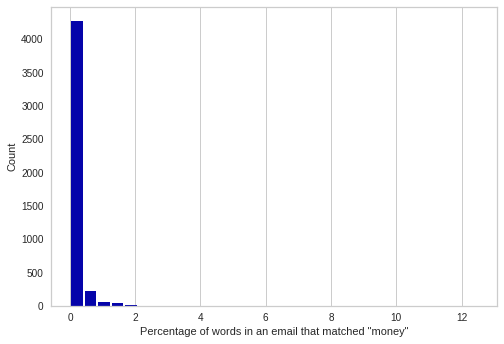

In [ ]:
# 3) Histogram of word_freq_money:
n, bins, patches = plt.hist(x=df['word_freq_money:'], bins=30, color='#0504aa', rwidth=0.85)
plt.grid(axis='y')
plt.xlabel('Percentage of words in an email that matched "money"')
plt.ylabel('Count')

### **Part 4:** 

### Below, I describe the importance of training and test data. I explain why we need to separate data into these subsets.

---

---


### Splitting our data into training and test data is important for the following reasons: Our main purpose in machine learning is to predict unseen data as well as possible. We need to essentially fake unseen data somehow in a way that allows us to see if our model will be able to generalize well if used on truly unseen data.

$~$

### In general, we randomly place around 75% - 90% - of all our observations (both for our features and our target) in our data into a training data set, while the remaining portion is placed in our test data set. We fit our model with our training data, but we set aside our test data so that our model never sees it until the point in time when we will evaluate the model to see how well it would perform on unseen data. Although we treat the test data as if it were unseen data (because the test data is indeed unseen by our model), the fact that we personally know the values that are in the test data (both features and the target) will enable us to evaluate our model, estimating how well it would perform on unseen data. 


---



### **Part 5:** 

### Below, I discuss what K-fold cross validation is and what we use it for:

---

---


### **Answer:** The idea behind K-fold cross validation is that when we train-test-split our data such that observations are randomly selected into either the training data set or the test data set, it is possible that the observations now comprising the training data set and test data set are not the best groupings of observations to have in each of these sets in order to get the most accurate predictions when we eventually use our model on unseen data. 

$~$

### If we can use a system whereby we are confident that the best combinations of observations that should be placed in our training data set and in our test data set to maximize the accuracy of our predictions are used, we can better establish how accurate one of our models is in comparison to other models we could also use for prediction. I.e. we could find which of our potential models to use, such as KNN Class validation, Unpenalized Logistic Regression, L1 Penalized Logistic Regression, L2 Penalized Logistic regression, etc. would be best model to use for prediction for a given dataset of interest based on which of the models had the highest prediction accuracy score when k-fold cross validation was used.

$~$

### In practice, the way we use K-fold cross validation is as follows: We specify how many different "folds" or segments of the total data we will use as our test data set for different iterations. If we choose K=5, e.g., it would divide our training data into 5 sections (i.e. each section would hold 20% of our data). It is important to remember that we use selection without replacement when we randomly generate each fold. 

$~$

### We could begin with the first fold/section of our data being used as our held-out test data set, and all remaining folds (constituting 80% of our data) being used as "training data." We would then establish a prediction accuracy rating when the first of the five folds are used as the test data set. Next, we would use the second 20% segment of the data as the held-out "test data," (with the other 80% of the data used as our "training data") and calculate a prediction accuracy score. We would next use the next 20 % of the data (i.e. our third fold) as the held-out test data set with the remaining 80% of the data as our "training data set," again establishing a prediction accuracy score. We would repeat this for all 5 folds, obtaining each of the 5 folds' prediction accuracy scores. Then we would average all 5 of the resulting prediction accuracy scores together to obtain as our overall prediction accuracy score for that model using our specified number of folds with K-fold cross validation.

$~$

### This process would be the same, e.g. if we set K equal to another value like K=10 for K-fold cross validation. The only difference in this case would be that each fold in the data would comprise 10% of the data to be used as our held-out "test" data set at a time (instead of 20% when K equaled 5) while the remaining 90% of the data would be used as our "training" data set. We would still take the average of all 10 prediction accuracy scores generated to use as our overall K-fold cross validation prediction accuracy score when K equaled 10. 


---





### **Part 6:** 

### Below, I discuss how is K-fold cross validation is different from stratified K-fold cross validation:

---

---


### **Answer:** K-fold cross validation is different from stratified K-fold cross validation in the following way:

### K-fold cross validation does not pay special attention to ensure that observations randonly selected into each fold have class frequencies in proportion to the class frequencies in the *entire* training dataset. However, stratified K-fold cross validation randomly selects observations into "training" data sets and "test" data sets from the *overall* training dataset but does so in a way that makes sure that class frequencies within each "training" and "test" set up for each split are consistent with the class frequencies found in the *overall* training dataset.

$~$

### K-fold cross validation is especially useful when there may be extreme class imbalances in our dataset to help ensure prediction accuracy scores are valid. If our data has severe class imbalances, it could very well be the case that a given "training" data set established by K-fold cross validation may not have any or very few observations with minority classes in them to train the model on. This could lead K-fold cross validation accuracy scores to be misleading and could lead a model to not predict well on unseen data. 


---



### **Part 7:** 

### For this portfolio example, I will use four different types of models to classify email texts as either spam or non-spam. These models include:

*   KNN Classification
*   L1 Penalized Logistic Regression
*   L2 Penalized Logistic Regression
*   Random Forest Classification

### I split the data into training and test subsets.  I then build models with the three variables in the dataset that I discussed above that I think will be good predictors of "spam".  I then describe why I chose particular parameters for my models. I then run the models and evaluate prediction error in two ways: A) On test data directly and B) using K-fold cross-validation.

---

### <u> KNN Classificaton: </u>

---



In [ ]:
#Here, I create y and X from the complete dataset

y = df['spam']
X = df.loc[:, df.columns != 'spam']

X.head()

,word_freq_make:,word_freq_address:,word_freq_all:,word_freq_3d:,word_freq_our:,word_freq_over:,word_freq_remove:,word_freq_internet:,word_freq_order:,word_freq_mail:,...,word_freq_conference:,char_freq_;:,char_freq_(:,char_freq_[:,char_freq_!:,char_freq_$:,char_freq_#:,capital_run_length_average:,capital_run_length_longest:,capital_run_length_total:
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [ ]:
#Next, I include just my 3 prefered features out of the complete dataset, and label this X3

y = df['spam']
X3 = df.loc[:, ['word_freq_free:', 'capital_run_length_total:', 'word_freq_money:']]

X3.head()

,word_freq_free:,capital_run_length_total:,word_freq_money:
0,0.32,278,0.00
1,0.14,1028,0.43
2,0.06,2259,0.06
3,0.31,191,0.00
4,0.31,191,0.00


### **Note:** From the following code, we can see that the classes are marginally imbalanced, with 61% of observations being non-spam, and 39% being spam. Even though the imbalance in the data is marginal, since it is possible that the presence of imbalanced data can lead to biased results, I will implement a resampling technique to balance the classes. Specifically, I will use the Synthetic Minority Oversampling Technique (SMOTE) in order to randomly generate new synthetic observations so that the two classes become balanced. SMOTE is generally regarded as a more promising technique for balancing imbalanced data than other techniques. In short, the technique randomly selects a given observation's K nearest neighbors, and then the difference is taken between this neighboring observation's value and the original observation's value being evaluated. This difference is then multiplied by a random value between 0 and 1, creating a new feature vector which thus becomes a new synthetic observation that is added to the dataset. The process continues until the data is balanced between classes.

In [ ]:
print(pd.Series(y).value_counts(normalize=True))

0    0.605955
1    0.394045
Name: spam, dtype: float64


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X3_sm, y_sm = smote.fit_resample(X3, y)

print(pd.Series(y_sm).value_counts(normalize=True))



1    0.5
0    0.5
Name: spam, dtype: float64


In [ ]:
#Here, I train test split X3 and y
from sklearn.model_selection import train_test_split

X3_train, X3_test, y_train, y_test = train_test_split(X3_sm, y_sm, random_state=42)

In [ ]:
#Next, I scale the data using Scikit Learn's StandardScaler, which makes the mean of each feature = 0 and the standard deviation = 1.
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = preprocessing.StandardScaler().fit(X3_train)
X3_train_scaled = scaler.transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

#Note: Using Column Transformer is not necessary for this data set because all features are numeric variables

### **KNN Classification - Choosing the Best Parameter:** The default K value for n_neighbors for KNN is 5. However, since 5 may not be the best parameter for n_neighbors, GridSearch will tune the model to discover which parameter for n_neighbors will return the best cross validation prediction accuracy score. Since KNN Classifier takes minimum Euclidean distance between a given observation and its n nearest neighbors and uses a "majority vote" to predict the class of the observation for the dependent variable under examination, it is important for GridSearchCV to look just at odd numbers for K such that there cannot be any ties.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold



#KNN Classification and GridSearchCV
 

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
print(knn_pipe.steps)




[('standardscaler', StandardScaler()), ('kneighborsclassifier', KNeighborsClassifier())]


In [ ]:
param_grid = {'kneighborsclassifier__n_neighbors': np.arange(1, 25, 2)} 
grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X3_train_scaled, y_train)
print("best mean cross-validation score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))



best mean cross-validation score: 0.8099
best parameters: {'kneighborsclassifier__n_neighbors': 19}


### **GridSearchCV's Identified Best Parameter for KNN Classification: 19**

### GridSearch CV iterated through all odd numbered K nearest neighbor options between 1 and 25 and found that 19 is the parameter that predicts best with the least complex model (i.e. lowest parameter for K that predicts the with the highest F1 score). Note that the F1 score is the harmonic mean between precision and recall.

### Now that we know the best parameter for K is 19, we can use 19 as the value for K and test **A:** on our test data directly and **B:** using K-fold cross validation on training data.

In [ ]:
from sklearn.metrics import f1_score

knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X3_train_scaled, y_train)

#A: On test data directly
y_preds_knn = knn.predict(X3_test_scaled)

print("KNN Classification Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_knn, average='weighted')))

#B: Using K-fold cross validation with the number of folds = 5
print("KNN Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(KNeighborsClassifier(n_neighbors=15), X3_train_scaled, y_train, cv=5, scoring='f1_weighted'))))



KNN Classification Test Set F1 Score (scaled): 0.7964
KNN Classification K-fold Cross Validation F1 Score (scaled): 0.8059


### **Answer:**

### The KNN Classification Test Set based F1 score is: **0.7964**

### The KNN Classification K-fold Cross Validation based F1 score is: **0.8059**






---

### **Part 8:** 

### <u> L1 Penalized Logistic Regression </u>

### After running this model, I will describe why I chose particular parameters for the model.

$~$

### I once again will evaluate prediction strength in two ways: **A)** On test data directly and **B)** using K-fold cross-validation.  I will explain whether this model predicted test data better than my previous model.

---

---


### **The difference between L1 and L2 regularized logistic regression:** L1 and L2 regularization both help to prevent logistic regression models from overfitting. Because both methods shrink down coefficients, they also have the benefit of enabling analysts to extract feature importance based on the resulting coefficients. L1 regularization creates a tunable penalty equal to λ times the sum of the absolute values of the parameters, while L2 regularization creates a tunable penalty equal to λ times the sum of the squares of the parameters. Scikit-Learn uses the tuning parameter C which equals the inverse of λ. A smaller value of C implies a higher penalty in both L1 and L2 regularization.

### **L1 Penalized Logistic Regression - Choosing the Best Parameter:**  L1 penalized logistic regression has the goal of shrinking the beta coefficients in the model such that features without much predictive power result in their beta coefficients shrinking all the way to 0, while only those features with some predictive power have ther beta coefficients remain in the model. This tends to increase the strength of predictions.

$~$

### As we decrease the value of C we increase the strength of the penalty in terms of how much the model's beta coefficients are forced to shrink. Therefore, the optimal C parameters for L1 penalized logistic regression tend to be low values. If we were to use a very high value for C such as 1e90, the logisticregression model would interpret this as unpenalized logistic regression.

$~$

### I opt to choose a range for GridSearchCV to iterate through from 0.001 to 3. Since (in general) the lower the value of C the higher the penalty, the lower the beta coefficients, and the higher the prediction accuracy, I believe that in all likelihood the optimal value of C that will be found will be less than 3.

$~$

### The more the model iterates through the more (in general) L1 penalized logistic regression can shrink betas, but at a certain point there is a cap to how much iterating helps increase prediction. I choose a high value for max_iter (100,000) to try to increase my prediction accuracy as much as possible.



In [ ]:
#L1 Penalized Logistic Regression and GridSearchCV
from sklearn.linear_model import LogisticRegression

l1_pipe = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', max_iter=100000, random_state=42, solver='liblinear'))
print(l1_pipe.steps)


[('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression(max_iter=100000, penalty='l1', random_state=42,
                   solver='liblinear'))]


In [ ]:
param_grid = {'logisticregression__C': np.logspace(-5,5)}
grid = GridSearchCV(l1_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X3_train_scaled, y_train)
print("best mean cross-validation score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation score: 0.7805
best parameters: {'logisticregression__C': 0.7906043210907702}


### **GridSearchCV's Identified Best C Parameter for L1 Penalized Logistic Regression: 0.7906043210907702** 



### Now that we know the best parameter value for C is 0.7906043210907702, we can use this value as the value for C and test A: on test our data directly and B: using K-fold cross validation.

In [ ]:
l1_3 = LogisticRegression(penalty='l1', C=0.7906043210907702, random_state=42, solver='liblinear')
l1_3.fit(X3_train_scaled, y_train)

#A: On test data directly

y_preds_l1 = l1_3.predict(X3_test_scaled)

print("L1 Penalized Logistic Regression Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_l1, average='weighted')))

#B: Using K-fold cross validation
print("L1 Penalized Logistic Regression K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(LogisticRegression(C=0.19306977288832497, penalty='l1', max_iter=100000, solver='liblinear', random_state=42), X3_train_scaled, y_train, cv=5, scoring='f1_weighted'))))


l1 Penalized Logistic Regression Test Set F1 Score (scaled): 0.7517
l1 Penalized Logistic Regression K-fold Cross Validation F1 Score (scaled): 0.7784


### **Answer:** 

### The L1 Penalized Logistic Regression Test Set-based F1 score would therefore be: **0.7517**

### The L1 Penalized Logistic Regression K-fold Cross Validation based F1 score would therefore be: **0.7784**

---

### **Answer:** L1 Penalized Logistic Regression *did not* predict better than my previous model (KNN Classification) because the KNN Classification Test Set based F1 score was **0.7964** and the KNN Classification K-fold Cross Validation based F1 score was **0.8059**, both higher than for L1 penalized logistic regression.
 

---


### **Part 9:** 

### <u> L2 Penalized Logistic Regression: </u>

### After running this model, I will describe why I chose particular parameters for the model.



### I once again will evaluate prediction strength in two ways: **A)** On test data directly and **B)** using K-fold cross-validation.  I will explain whether this model predicted test data better than my previous model.

---
---

### **L2 Penalized Logistic Regression - Choosing the Best Parameter:**

### L2 penalized logistic regression has the goal of shrinking the beta coefficients in the model such that features without much predictive power result in their beta coefficients shrinking, but not quite to 0. The beta coefficients for those predictors with more predictive power will be higher than the beta coefficients with less predictive power. Shrinking the coefficients in this way also tends to increase the accuracy of predictions. 

$~$

### Like L1 penalized logistic regression, with L2 penalized logistic regression as we decrease the value of C we increase the strength of the penalty in terms of how much the model's beta coefficients are forced to shrink. Therefore, the optimal C parameters for L2 penalized logistic regression also tend to be low values.

$~$

### I opt to choose a range for GridSearchCV to iterate through from 0.001 to 3. Since (in general) the lower the value of C the higher the penalty, the lower the beta coefficients, and the higher the prediction accuracy, I believe that in all likelihood the optimal value of C that will be found will be less than 3.

$~$

### The more the model iterates through the more (in general) L2 penalized logistic regression also can shrink betas, but - again - at a certain point there is a cap to how much iterating helps increase prediction. I choose a high value for max_iter (100,000) to try to increase my prediction accuracy as much as possible.


In [ ]:
#L2 Penalized Logistic Regression and GridSearchCV
from sklearn.linear_model import LogisticRegression

l2_pipe = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', max_iter=100000, random_state=42))
print(l2_pipe.steps)

[('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression(max_iter=100000, random_state=42))]


In [ ]:
param_grid = {'logisticregression__C': np.logspace(-5,5)}
grid = GridSearchCV(l2_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X3_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation F1 score: 0.7805
best parameters: {'logisticregression__C': 1.2648552168552958}


### **GridSearchCV's Identified Best C Parameter for L2 Penalized Logistic Regression: 1.2648552168552958** 

### Now that we know the best parameter value for C is 1.2648552168552958, we can use this value as the value for C and test **A:** on test our data directly and **B:** using K-fold cross validation.

In [ ]:
l2_3 = LogisticRegression(C=1.2648552168552958, penalty='l2', max_iter=100000, random_state=42)
l2_3.fit(X3_train_scaled, y_train)

#A: On test data directly

y_preds_l2 = l2_3.predict(X3_test_scaled)

print("l2 Penalized Logistic Regression Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_l2, average='weighted')))

#B: Using k-fold cross validation
print("l2 Penalized Logistic Regression K-fold Cross Validation F1 (scaled): {:.4f}".format(np.mean(cross_val_score(LogisticRegression(C=1.1539954105566927, penalty='l2', max_iter=100000, random_state=42), X3_train_scaled, y_train, cv=5, scoring='f1_weighted'))))


l2 Penalized Logistic Regression Test Set F1 Score (scaled): 0.7532
l2 Penalized Logistic Regression K-fold Cross Validation F1 (scaled): 0.7803


### **Answer:** 

### The L2 Penalized Logistic Regression Test Set based F1 score is therefore: **0.7532**

### The L2 Penalized Logistic Regression K-fold Cross Validation based F1 score is therefore: **0.7803**


---


### **Answer:** Yes, L2 Penalized Logistic Regression did predict slightly better than my previous model (L1 Penalized Logistic Regression) because the L1 Penalized Logistic Regression Test Set-based F1 score was **0.7517** and the L1 Penalized Logistic Regression K-fold Cross Validation-based F1 score was **0.7784**.

---


### **Part 10:** 

### <u> Random Forests Classification: </u>

### After running this model, I will describe why I chose particular parameters for the model.

$~$

### I once again will evaluate prediction strength in two ways: **A)** On test data directly and **B)** using K-fold cross-validation.  I will explain whether this model predicted test data better than my previous model.

---

---

### **Random Forests - Choosing the Best Parameter:**

### There are several different hyperparameters that can be helpful to tune when using Random Forests:

$~$

### The higher the number of values tuned for on most of these hyperparameters, the longer it takes for the model to run and produce output. The key is to find values for the hyperparameters that still produce relatively high prediction accuracy scores while limiting the amount of time needed to run the model.  

$~$

*   **n_estimators** creates bootstrap datasets (synthetically created datasets that are randomly generated from the original dataset) which the model uses to essentially expand the amount of data to train on. Generally, the higher the number of bootstrap datasets created with n_estimators, the more accurate my predictions will be. However, at some point each additional number of bootstrap dataset will lead to less and less increases in accuracy. It is at the same time important to use minimally complexity (in terms of the level of our hyperparameters) for any given model. Using GridSearchCV, I tuned for different ranges of n_estimators to see what additional predictive value different increments of maximum values in the range to be tested would provide. I found that a maximum value for n_estimators of 10,000 returned a mean cross-validation score of 0.8179. Yet, the time it took to run this model was about a half-hour. Since our goal is to have our models be minimally complex yet maximally accurate, I decided instead to tune between 1 and 10 for n_estimators. The time it now took to run the model decreased substantially, and my cross-validation score actually increased. I therefore kept my tuning range between 1 and 10.

$~$

*   **max_depth** is the number of times you split each internal node. The higher the value for max_depth the more predition accuracy tends to increase, although there is a point at which each additional integer added for max_depth will lead to less and less increases in accuracy for the model. The higher the number of internal splits allowed by increasing the value on max_depth the larger will be the size of the tree. I learned the lesson from my experience with selecting ranges to test with n_estimators that perhaps a small range would also be best to use for max_depth as having a small range would decrease the complexity of the model, and thus the time needed to run the model. I selected my range for max_depth to be fom 1 to 10.

$~$

*   **criterion** is the method used for finding the error rate for classification prediction for the categorical values on the dependent variable at each split while conducting recursive binary splitting, finding new splits with the minimum error rate, which ultimately increases prediction accuracy. The methods that can be used with classification (Gini Index vs. Cross-Entropy) are very similar in their methodological design. They are both measurements of classification purity whereby the smaller the value from the method obtained (i.e. the closer to 0 the value you get is) for the Gini Index or Cross Entropy score the more accurately your model is classifying specific categories for your observations on the dependent variable.  I attempted to see which of these criterion would predict more accurately with our dataset by including both in my GridSearchCV pipeline.

$~$

*   **min_samples_leaf** allows you to control the number of observations permitted in each of our terminal nodes. Thus, an increased value for min_samples_leaf decreases the size of the trees in our model. It is possible that increasing min_samples_leaf will increase prediction accuracy but only up to a certain point. To maintain a minimally complex model I chose a small range from 1 to 10 to tune min_samples_leaf.

$~$

*   **max_features** is the number of features we permit our model to randomly include for evaluation at each internal node. The idea behind max_features is that by limiting the number of features that can be evaluated at each internal node, you make your trees more different, which thus can help the generalizability of your model when it is tested on unseen data. Although the square root of the total number of features in a given data set is typically thought to be a good value to use for maximizing prediction accuracy on unseen data, I wanted to see if for this particular data set their might be an even better max_feature value that would increase accuracy. I therefore tested for the full range of features in the data set. Since I have only 3 features in my model up to this point, I will tune for max_features range of [1, 3].








In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
print(rf_pipe.steps)



[('standardscaler', StandardScaler()), ('randomforestclassifier', RandomForestClassifier(random_state=42))]


In [ ]:
param_grid = {
    'randomforestclassifier__n_estimators': [1, 2000],
    'randomforestclassifier__max_features': [1, 3],
    'randomforestclassifier__max_depth': [1, 1000],
    'randomforestclassifier__min_samples_leaf': [1, 100],
    'randomforestclassifier__criterion': ['gini', 'entropy']}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X3_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation F1 score: 0.8188
best parameters: {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 1000, 'randomforestclassifier__max_features': 1, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 2000}


### **GridSearchCV's Identified Best Parameters for Random Forests Classification:**


*   ***Criterion:*** gini
*   ***Max_depth:*** 1000
*   ***Max_features:*** 1
*   ***Min_samples_leaf:*** 1
*   ***N_estimators:*** 2000







### Now that we know the best parameters within the range provided, we can use these to create Random Forest models **A:** to test our data directly and **B:** using K-fold cross validation.

In [ ]:
rf_3 = RandomForestClassifier(criterion='gini', max_depth=1000, max_features=1, min_samples_leaf=1, n_estimators=2000, random_state=42)
rf_3.fit(X3_train_scaled, y_train)

#A: On test data directly

y_preds_rf = rf_3.predict(X3_test_scaled)
print("Random Forests Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_rf, average='weighted')))

#B: Using K-fold cross validation
print("Random Forests Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(RandomForestClassifier(criterion='entropy', max_depth=10, max_features=1, min_samples_leaf=10, n_estimators=10, random_state=42), X3_train_scaled, y_train, cv=5, scoring='f1_weighted'))))


Random Forests Test Set F1 Score (scaled): 0.8030
Random Forests Classification K-fold Cross Validation F1 Score (scaled): 0.8126


### **Answer:**

### The Random Forests Classification Test Set-based F1 Score is: **0.8030**

### The Random Forests Classification K-fold Cross Validation-based F1 Score therefore is: **0.8126**

---


### **Answer:** Yes, Random Forests Classification did predict better than my previous model (L2 Penalized Logistic Regression) because the L2 Penalized Logistic Regression Test Set-based F1 score was **0.7532** and the L2 Penalized Logistic Regression K-fold Cross Validation based error rate was **0.7803**

---


### **Part 11:** 

### Now I will rerun my best model (Random Forests), but this time add three new variables to the model that I think will increase prediction strength. I will see if this new model predicts test data better than my previous models.

---

---

### My best model from Questions 8 - 11 was: ***Random Forests***

### The 3 extra variables that I think will further increase the model's accuracy are: 


*   word_freq_order:
*   word_freq_receive:
*   char_freq_!:

$~$

### ***word_freq_order:*** This feature may be predictive because advertisers and scam artists alike have incentives to try to persuade ordinary people to order things from them. Alternatively, they also have an incentive to try to make gullible people think they have an order that is ready for them if they respond to the email. The sender of an email may believe that a high frequency of the word "order" may persuade people to be more inclined to desire to order things or more likely to believe they have an order waiting for them if they respond.

$~$

### ***word_freq_receive:*** This feature may be predictive because advertisers and scam artists have an incentive to try to lure people into thinking that they will receive items if they respond to an email. Naturally, most people like to receive things. Therefore, the more often the word "receive" is used in an email, the sender of the email may be more likely to think they will receive a response.

$~$

### ***char_freq_!:*** This feature may be predictive because the use of an exclamation mark can have the purpose of trying to get the attention of someone or trying to excite someone about an offer being advertised. The sender may believe that the more often they use exclamation marks the more often readers will in fact pay attention and will become excited about any such offer being advertised.




In [ ]:
#Here, I create a new datset that combines the three features I previously used as well as the three additional features mentioned directly above:

y = df['spam']
X6 = df.loc[:, ['word_freq_free:', 'capital_run_length_total:', 'word_freq_money:', 'word_freq_order:', 'word_freq_receive:', 'char_freq_!:']]

X6.head()


,word_freq_free:,capital_run_length_total:,word_freq_money:,word_freq_order:,word_freq_receive:,char_freq_!:
0,0.32,278,0.00,0.00,0.00,0.778
1,0.14,1028,0.43,0.00,0.21,0.372
2,0.06,2259,0.06,0.64,0.38,0.276
3,0.31,191,0.00,0.31,0.31,0.137
4,0.31,191,0.00,0.31,0.31,0.135


In [ ]:
from imblearn.over_sampling import SMOTE

#I again use SMOTE to balance the classes:

smote = SMOTE(random_state=42)
X6_sm, y_sm = smote.fit_resample(X6, y)

print(pd.Series(y_sm).value_counts(normalize=True))

1    0.5
0    0.5
Name: spam, dtype: float64


In [ ]:
#Train test split

X6_train, X6_test, y_train, y_test = train_test_split(X6_sm, y_sm, random_state=42)

In [ ]:
#Scaling the data

scaler6 = preprocessing.StandardScaler().fit(X6_train)
X6_train_scaled = scaler6.transform(X6_train)
X6_test_scaled = scaler6.transform(X6_test)

In [ ]:
param_grid = {
    'randomforestclassifier__n_estimators': [1, 2000],
    'randomforestclassifier__max_features': [1, 6],
    'randomforestclassifier__max_depth': [1, 1000],
    'randomforestclassifier__min_samples_leaf': [1, 100],
    'randomforestclassifier__criterion': ['gini', 'entropy']}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X6_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation F1 score: 0.8746
best parameters: {'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 1000, 'randomforestclassifier__max_features': 1, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 2000}


In [ ]:
#Rerunning my best model (Random Forests) from before, but now with 6 features instead of 3:

rf_6 = RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=1, min_samples_leaf=1, n_estimators=2000, random_state=42)
rf_6.fit(X6_train_scaled, y_train)

#A: On test data directly
#print("Random Forests Classification Test Set Score Accuracy (scaled): {:.4f}".format(rf_6.score(X6_test_scaled, y_test)))
y_preds_6_rf = rf_6.predict(X6_test_scaled)
print("Random Forests Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_6_rf, average='weighted')))


#B: Using k-fold cross validation
print("Random Forests Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(RandomForestClassifier(criterion='gini', max_depth=1000, max_features=1, min_samples_leaf=1, n_estimators=2000, random_state=42), X6_train_scaled, y_train, cv=5, scoring='f1_weighted'))))


Random Forests Test Set F1 Score (scaled): 0.8809
Random Forests Classification K-fold Cross Validation F1 Score (scaled): 0.8737


### **Answer:** Yes, my best model now comprising 6 features outperformed my best model with only 3 features in terms of ***test data prediction strength*** (See the highlighted test set F1 scores for the two models below for comparison):

---

### Random Forests Classification Model (**3 Features**) - Test Set F1 Score (scaled):
### ***0.8030***


### Random Forests Classification Model (**3 Features**) - K-fold Cross Validation F1 Score (scaled): ***0.8126***


---
### Random Forests Classification Model (**6 Features**) - Test Set F1 Score (scaled):
### ***0.8809***

### Random Forests Classification Model (**6 Features**) - K-fold Cross Validation F1 Score (scaled): ***0.8737***


---




### **Part 12:** 

### Next, I rerun all my other models with this final set of six variables, evaluate prediction strength, and choose a final model.  I explain why I selected my final model among all of the models that I have run.  

---

---


In [ ]:
#KNN classification model, but now with 6 variables
#First, I'll use GridSearchCV to tune for the optimal number of K neighbors for the revised dataset with 6 features

param_grid = {'kneighborsclassifier__n_neighbors': np.arange(1, 25, 2)} 
grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X6_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation F1 score: 0.8631
best parameters: {'kneighborsclassifier__n_neighbors': 7}


In [ ]:
from pandas.core.common import random_state
#GridSearchCV found the optimal number of K neighbors for the revised dataset to be 7

knn_6 = KNeighborsClassifier(n_neighbors=7)
knn_6.fit(X6_train_scaled, y_train)

#A: On test data directly
#print("KNN Classification Test Set Score Accuracy (scaled): {:.4f}".format(knn_6.score(X6_test_scaled, y_test)))

y_preds_6_knn = knn_6.predict(X6_test_scaled)

print("KNN Classification Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_6_knn, average='weighted')))

#B: Using k-fold cross validation with the number of folds = 5
print("KNN Classification Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(KNeighborsClassifier(n_neighbors=5), X6_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

KNN Classification Test Set F1 Score (scaled): 0.8471
KNN Classification Cross Validation F1 Score (scaled): 0.8614


### **Answer:**

### The KNN Classification Test Set-based F1 Score is: **0.8471**

### The KNN Classification Cross Validation-based F1 Score is: **0.8614**

In [ ]:
#L1 Penalized Logistic Regression model, but now with 6 variables

param_grid = {'logisticregression__C': np.logspace(-5,5)}
grid = GridSearchCV(l1_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X6_train_scaled, y_train)
print("best mean cross-validation score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation score: 0.8153
best parameters: {'logisticregression__C': 0.30888435964774846}


In [ ]:
l1_6 = LogisticRegression(penalty='l1', C=0.30888435964774846, random_state=42, solver='liblinear')
l1_6.fit(X6_train_scaled, y_train)

#A: On test data directly
y_preds_6_l1 = l1_6.predict(X6_test_scaled)

print("L1 Penalized Logistic Regression Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_6_l1, average='weighted')))

#B: Using k-fold cross validation
print("L1 Penalized Logistic Regression K-fold Cross Validation Accuracy (scaled): {:.4f}".format(np.mean(cross_val_score(LogisticRegression(C=3.2374575428176464, max_iter=100000, random_state=42), X6_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

l1 Penalized Logistic Regression Test Set F1 Score (scaled): 0.7855
l1 Penalized Logistic Regression K-fold Cross Validation Accuracy (scaled): 0.8150


### **Answer:**

### The L1 Penalized Logistic Regression Test Set-based F1 Score is: **0.7855**

### The L1 Penalized Logistic Regression K-fold Cross Validation F1 Score is: **0.8150**

In [ ]:
#L2 Penalized Logistic Regression model, but now with 6 variables

param_grid = {'logisticregression__C': np.logspace(-5,5)}
grid = GridSearchCV(l2_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X6_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))


best mean cross-validation F1 score: 0.8151
best parameters: {'logisticregression__C': 0.30888435964774846}


In [ ]:
l2_6 = LogisticRegression(C=0.30888435964774846, penalty='l2', max_iter=100000, random_state=42)
l2_6.fit(X6_train_scaled, y_train)

#A: On test data directly

y_preds_6_l2 = l2_6.predict(X6_test_scaled)

print("L2 Penalized Logistic Regression Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_6_l2, average='weighted')))

#B: Using k-fold cross validation
print("L2 Penalized Logistic Regression K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(LogisticRegression(C=0.30888435964774846, max_iter=100000, random_state=42), X6_train_scaled, y_train, cv=5, scoring='f1_weighted'))))


l2 Penalized Logistic Regression Test Set F1 Score (scaled): 0.7862
l2 Penalized Logistic Regression K-fold Cross Validation F1 Score (scaled): 0.8154


### **Answer:**

### The L2 Penalized Logistic Regression Test Set-based F1 Score is: **0.7862**

### The L2 Penalized Logistic Regression K-fold Cross Validation-based F1 Score is: **0.8154**



### **Answer:** All of my other models F1 scores also increased by including 6 rather than just 3 features. This demonstrates that including more (useful) features can often improve the predictive strength of a model:

*   For KNN Classification, the test set F1 score increased from 0.7964 to 0.8471, and the K-fold cross validation F1 score increased from 0.8059 to 0.8614.

*   For L1 Penalized Logistic Regression, the test set F1 score increased from 0.7517 to 0.7855, and the K-fold cross validation F1 score increased from 0.7784 to 0.8150.

*   For L2 Penalized Logistic Regression, the test set F1 score increased from 0.7532 to 0.7862, and the K-fold cross validation F1 score increased from 0.7803 to 0.8154.

$~$

### **Answer (Continued):** For my final model, ***I select the Random Forests Classification model*** with 6 features because it produces the highest test set F1 score <mark>***(0.8809)***</mark>, and the highest F1 score with K-fold cross validation <mark>***(0.8737)***</mark> compared to all of my other models.

$~$

### *With these scores, it should be kept in mind that cross validated prediction rates are often a better indicator of a model's generalizability to unseen data than test set prediction rates.*    

---


### **Part 13:**

### I next see just how much of an improvement in predictive strength occurs when I include the full set of features in the dataset for each of the algorithms used for my prior models:

---
---


### Preprocessing:

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

print(pd.Series(y_sm).value_counts(normalize=True))

1    0.5
0    0.5
Name: spam, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, random_state=42)

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### KNN:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold



#KNN Classification and GridSearchCV
 

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
print(knn_pipe.steps)

[('standardscaler', StandardScaler()), ('kneighborsclassifier', KNeighborsClassifier())]


In [ ]:
param_grid = {'kneighborsclassifier__n_neighbors': np.arange(1, 25, 2)} 
grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train_scaled, y_train)
print("best mean cross-validation score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation score: 0.9244
best parameters: {'kneighborsclassifier__n_neighbors': 1}


In [ ]:
from sklearn.metrics import f1_score

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

#A: On test data directly
y_preds_all_knn = knn.predict(X_test_scaled)

print("KNN Classification Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_all_knn, average='weighted')))

#B: Using k-fold cross validation with the number of folds = 5
print("KNN Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(KNeighborsClassifier(n_neighbors=1), X_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

KNN Classification Test Set F1 Score (scaled): 0.9275
KNN Classification K-fold Cross Validation F1 Score (scaled): 0.9244


---

### The KNN Classification Test Set-based F1 Score is: **0.9275**
### The KNN Classification Cross Validation-based F1 Score is: **0.9244**

---

### L1 Penalized Logistic Regression:

In [ ]:
#L1 Penalized Logistic Regression and GridSearchCV
from sklearn.linear_model import LogisticRegression

l1_pipe = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', max_iter=100000, random_state=42, solver='liblinear'))
print(l1_pipe.steps)

[('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression(max_iter=100000, penalty='l1', random_state=42,
                   solver='liblinear'))]


In [ ]:
param_grid = {'logisticregression__C': np.logspace(-5,5)}
grid = GridSearchCV(l1_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train_scaled, y_train)
print("best mean cross-validation score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation score: 0.9340
best parameters: {'logisticregression__C': 1.2648552168552958}


In [ ]:
l1_all = LogisticRegression(penalty='l1', C=1.2648552168552958, random_state=42, solver='liblinear')
l1_all.fit(X_train_scaled, y_train)

#A: On test data directly

y_preds_all_l1 = l1_all.predict(X_test_scaled)

print("L1 Penalized Logistic Regression Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_all_l1, average='weighted')))

#B: Using k-fold cross validation
print("L1 Penalized Logistic Regression K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(LogisticRegression(C=1.2648552168552958, penalty='l1', max_iter=100000, solver='liblinear', random_state=42), X_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

l1 Penalized Logistic Regression Test Set F1 Score (scaled): 0.9232
l1 Penalized Logistic Regression K-fold Cross Validation F1 Score (scaled): 0.9333


---

### The L1 Penalized Logistic Regression Test Set-based F1 Score is: **0.9232**
### The L1 Penalized Logistic Regression Cross Validation-based F1 Score is: **0.9333**

---

### L2 Penalized Logistic Regression:

In [ ]:
#L2 Penalized Logistic Regression and GridSearchCV
from sklearn.linear_model import LogisticRegression

l2_pipe = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', max_iter=100000, random_state=42))
print(l2_pipe.steps)

[('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression(max_iter=100000, random_state=42))]


In [ ]:
param_grid = {'logisticregression__C': np.logspace(-5,5)}
grid = GridSearchCV(l2_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation F1 score: 0.9333
best parameters: {'logisticregression__C': 33.9322177189533}


In [ ]:
l2_all = LogisticRegression(C=33.9322177189533, penalty='l2', max_iter=100000, random_state=42)
l2_all.fit(X_train_scaled, y_train)

#A: On test data directly

y_preds_all_l2 = l2_all.predict(X_test_scaled)

print("L2 Penalized Logistic Regression Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_all_l2, average='weighted')))

#B: Using K-fold cross validation
print("L2 Penalized Logistic Regression K-fold Cross Validation F1 (scaled): {:.4f}".format(np.mean(cross_val_score(LogisticRegression(C=33.9322177189533, penalty='l2', max_iter=100000, random_state=42), X_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

l2 Penalized Logistic Regression Test Set F1 Score (scaled): 0.9232
l2 Penalized Logistic Regression K-fold Cross Validation F1 (scaled): 0.9333


---

### The L2 Penalized Logistic Regression Test Set-based F1 Score is: **0.9232**
### The L2 Penalized Logistic Regression Cross Validation-based F1 Score is: **0.9333**

---

### Random Forests:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

rf_pipe = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
print(rf_pipe.steps)

[('standardscaler', StandardScaler()), ('randomforestclassifier', RandomForestClassifier(random_state=42))]


In [ ]:
param_grid = {
    'randomforestclassifier__n_estimators': [1, 2000],
    'randomforestclassifier__max_features': [1, 3],
    'randomforestclassifier__max_depth': [1, 1000],
    'randomforestclassifier__min_samples_leaf': [1, 100],
    'randomforestclassifier__criterion': ['gini', 'entropy']}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train_scaled, y_train)
print("best mean cross-validation F1 score: {:.4f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))

best mean cross-validation F1 score: 0.9658
best parameters: {'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 1000, 'randomforestclassifier__max_features': 3, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 2000}


In [ ]:
rf_all = RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=3, min_samples_leaf=1, n_estimators=2000, random_state=42)
rf_all.fit(X_train_scaled, y_train)

#A: On test data directly

y_preds_all_rf = rf_all.predict(X_test_scaled)
print("Random Forests Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_all_rf, average='weighted')))

#B: Using K-fold cross validation
print("Random Forests Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=3, min_samples_leaf=1, n_estimators=2000, random_state=42), X_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

Random Forests Test Set F1 Score (scaled): 0.9577
Random Forests Classification K-fold Cross Validation F1 Score (scaled): 0.9658


---

### The Random Forests Test Set-based F1 Score is: **0.9577**
### The Random Forests Cross Validation-based F1 Score is: **0.9658**

---


---
---

### **Part 14:**

### Next, I take my best model - Random Forests Classifier using all features in the dataset, and use Recursive Feature Elimination (RFE) and compare it to the Random Forests Classifier algorithm's own internal feature importance technique of identifying which features are most important. I.e., I see how similar each feature importance technique's top 10 features are to each other's.

---
---

### ***Explanation of Recursive Feature Elimination (RFE):***
---
---

### In short, RFE works by first starting out with the full set of features, evaluating the prediction strength of a model fit to these features. It then drops a feature from the model, one at a time, then refits the model to the remaining features, and reevaluates prediction strength each time a feature is dropped. The feature that is dropped from the model each time is the feature found to contribute the least to the overall prediction strength, measured by a prespecified scoring metric. It is possible to drop more than one feature at a time, though in the example below I drop one feature at a time.

In [ ]:
#Here I first use RFECV() to identify the optimal number of features that should be use to maximize overall predictive strength, and then I plot the results showing my model's weighted F1 scores
#per number of features used in the model. This requires that max_features be in (percentage) float format rather than interger format, so I convert max features of 3 into a porportion of the total 
#number of features below.

print(X.shape)

print(3/57)

(4601, 57)
0.05263157894736842


Optimal number of features : 55


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:103: FutureWarning: The `grid_scores_` attribute is deprecated in version 1.0 in favor of `cv_results_` and will be removed in version 1.2.
  warnings.warn(msg, category=FutureWarning)


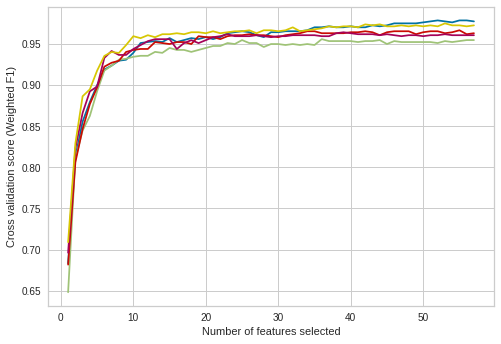

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification

min_features_to_select = 1

min_features_to_select = 1  # Minimum number of features to consider
rfecv = RFECV(
    estimator = RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=0.05263157894736842, min_samples_leaf=1, n_estimators=2000, random_state=42),
    step=1,
    cv=KFold(5),
    scoring="f1_weighted",
    min_features_to_select=min_features_to_select,
)
rfecv.fit(X_train_scaled, y_train)

print("Optimal number of features : %d" % rfecv.n_features_)

# Plot number of features VS. cross-validation scores
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (Weighted F1)")
plt.plot(
    range(min_features_to_select, len(rfecv.grid_scores_) + min_features_to_select),
    rfecv.grid_scores_,
)
plt.show()

### Here we can see the optimal number of features to maximize the weighted F1 score is 55. However, the graph shows that after about 10 -12 features, there is very little improvement in the model's weighted F1 score. In a production environment, it can be better to keep models relatively simple in terms of the amount of data used for training and prediction to save time and data storage resources. I will therefore seek to find the top 12 features both through Recursive Feature Elimination and through the Random Forest Classifier's built-in feature importance identification technique. Both techniques are briefly explained further below.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

estimator = RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=0.05263157894736842, min_samples_leaf=1, n_estimators=2000, random_state=42).fit(X_train_scaled, y_train)

selector = RFE(estimator, n_features_to_select=1, step=1)
selector = selector.fit(X_train_scaled, y_train)

In [ ]:
print('Feature Ranking: %s' % selector.ranking_)
rfe_support = selector.get_support()
rfe_feature = X.loc[:,rfe_support].columns.tolist()
print(rfe_feature, 'selected features')

Feature Ranking: [35 28 17 55 11 26  6 23 30 21 27 18 39 50 44  8 22 25 10 33  3 51 14 12
  9 16 13 34 38 31 45 54 40 53 37 42 24 56 43 52 49 29 48 41 20 19 57 47
 36 15 46  2  5 32  1  7  4]
['capital_run_length_average:'] selected features


### Below, I list all column names in the order they appear in the original X dataframe. The "Feature Ranking" list given in the RFE output above contains the same order of features as specified in the list below. However, in the "Feature Ranking" list above, each value that is listed in place of the feature name is the respective RFE ranking of that feature. E.g., 'word_freq_make:' is the 35th most predictively strong feature in the dataset, 'word_freq_address:' is the 28th most predictively strong feature, and 'word_freq_all:' is the 17th most predictively strong feature:

In [ ]:
list(enumerate(X.columns))


[(0, 'word_freq_make:'),
 (1, 'word_freq_address:'),
 (2, 'word_freq_all:'),
 (3, 'word_freq_3d:'),
 (4, 'word_freq_our:'),
 (5, 'word_freq_over:'),
 (6, 'word_freq_remove:'),
 (7, 'word_freq_internet:'),
 (8, 'word_freq_order:'),
 (9, 'word_freq_mail:'),
 (10, 'word_freq_receive:'),
 (11, 'word_freq_will:'),
 (12, 'word_freq_people:'),
 (13, 'word_freq_report:'),
 (14, 'word_freq_addresses:'),
 (15, 'word_freq_free:'),
 (16, 'word_freq_business:'),
 (17, 'word_freq_email:'),
 (18, 'word_freq_you:'),
 (19, 'word_freq_credit:'),
 (20, 'word_freq_your:'),
 (21, 'word_freq_font:'),
 (22, 'word_freq_000:'),
 (23, 'word_freq_money:'),
 (24, 'word_freq_hp:'),
 (25, 'word_freq_hpl:'),
 (26, 'word_freq_george:'),
 (27, 'word_freq_650:'),
 (28, 'word_freq_lab:'),
 (29, 'word_freq_labs:'),
 (30, 'word_freq_telnet:'),
 (31, 'word_freq_857:'),
 (32, 'word_freq_data:'),
 (33, 'word_freq_415:'),
 (34, 'word_freq_85:'),
 (35, 'word_freq_technology:'),
 (36, 'word_freq_1999:'),
 (37, 'word_freq_parts:

---
---

### **The top 12 features identified by RFE:**

1. 'capital_run_length_average:'
2. 'char_freq_!:'
3. 'word_freq_your:'
4. 'capital_run_length_total:'
5. 'char_freq_$:'
6. 'word_freq_remove:'
7. 'capital_run_length_longest:'
8. 'word_freq_free:'
9. 'word_freq_hp:'
10. 'word_freq_you:'
11. 'word_freq_our:'
12. 'word_freq_money:'

---
---


In [ ]:
#Next, I subset the original X dataframe to list the top 12 features found by RFE:
X_top_12_rfe = X[['capital_run_length_average:','char_freq_!:','word_freq_your:','capital_run_length_total:','char_freq_$:','word_freq_remove:','capital_run_length_longest:','word_freq_free:','word_freq_hp:','word_freq_you:','word_freq_our:','word_freq_money:']]
X_top_12_rfe.head()

,capital_run_length_average:,char_freq_!:,word_freq_your:,capital_run_length_total:,char_freq_$:,word_freq_remove:,capital_run_length_longest:,word_freq_free:,word_freq_hp:,word_freq_you:,word_freq_our:,word_freq_money:
0,3.756,0.778,0.96,278,0.000,0.00,61,0.32,0.0,1.93,0.32,0.00
1,5.114,0.372,1.59,1028,0.180,0.21,101,0.14,0.0,3.47,0.14,0.43
2,9.821,0.276,0.51,2259,0.184,0.19,485,0.06,0.0,1.36,1.23,0.06
3,3.537,0.137,0.31,191,0.000,0.31,40,0.31,0.0,3.18,0.63,0.00
4,3.537,0.135,0.31,191,0.000,0.31,40,0.31,0.0,3.18,0.63,0.00


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_sm_top_12_rfe, y_sm = smote.fit_resample(X_top_12_rfe, y)

print(pd.Series(y_sm).value_counts(normalize=True))

1    0.5
0    0.5
Name: spam, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sm_top_12_rfe, y_sm, random_state=42)

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf_top_12_rfe = RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=3, min_samples_leaf=1, n_estimators=2000, random_state=42)
rf_top_12_rfe.fit(X_train_scaled, y_train)

#A: On test data directly

y_preds_top_12_rfe_rf = rf_top_12_rfe.predict(X_test_scaled)
print("Random Forests Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_top_12_rfe_rf, average='weighted')))

#B: Using K-fold cross validation
print("Random Forests Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=3, min_samples_leaf=1, n_estimators=2000, random_state=42), X_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

Random Forests Test Set F1 Score (scaled): 0.9376
Random Forests Classification K-fold Cross Validation F1 Score (scaled): 0.9503


---
---
### Using the top 12 features (in my previous Random Forests model) identified by RFE instead of the full set of features results in the test set F1 score decreasing from 0.9577 to <mark>0.9376</mark> and the K-fold cross validation F1 score decreasing from 0.9658 to <mark>0.9503</mark>.

---
---


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

print(pd.Series(y_sm).value_counts(normalize=True))

1    0.5
0    0.5
Name: spam, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, random_state=42)

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf_all = RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=3, min_samples_leaf=1, n_estimators=2000, random_state=42)
rf_all.fit(X_train_scaled, y_train)

#A: On test data directly

y_preds_all_rf = rf_all.predict(X_test_scaled)
print("Random Forests Test Set F1 Score (scaled): {:.4f}".format(f1_score(y_test, y_preds_all_rf, average='weighted')))

#B: Using K-fold cross validation
print("Random Forests Classification K-fold Cross Validation F1 Score (scaled): {:.4f}".format(np.mean(cross_val_score(RandomForestClassifier(criterion='entropy', max_depth=1000, max_features=3, min_samples_leaf=1, n_estimators=2000, random_state=42), X_train_scaled, y_train, cv=5, scoring='f1_weighted'))))

Random Forests Test Set F1 Score (scaled): 0.9577
Random Forests Classification K-fold Cross Validation F1 Score (scaled): 0.9658


---
---

### **Description of Random Forest Classifier's Feature Importance Technique - Mean Decrease in Impurity (MDI):**

$~$

### Feature selection is known to be important because it can improve model predictive strength and processing time. Random Forests determines a given feature's importance by first finding the level of node importance by calculating the amount of total decision tree impurity decreased in a given node multiplied by the probability of each observation reaching that node. E.g., supposing that a single Random Forest decision tree has just two child nodes, the equation for each child node's level of importance for that tree is first calculated by $ni_{j}$ = $w_{j}C_{j}$ - $w_{left(j)}C_{left(j)}$ - $w_{right(j)}C_{right(j)}$ where $ni_{j}$ is the level of node j's importance, $w_{j}$ is the weighted number of observations ending up in node j, $C_{j}$ is the level of impurity found in node j, left(j) is the left most child node resulting from node j's split, and right(j) is the right most child node resulting from the split. Then each feature's level of importance ($f_{i}$) in a given decision tree is calculated using the formula:




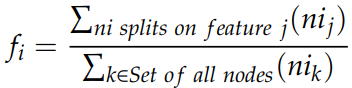

### $f_{i}$ is then normalized to values between 0 and 1 using the formula:

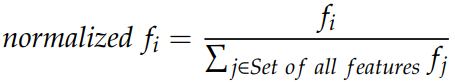

### The sum is then taken of ***normalized*** $f_{i}$ across all nodes involving feature ***i*** for *each* decision tree, and then the total sum of ***normalized*** $f_{i}$ for all decision trees in the ensemble are averaged together.

$~$

### It is important to keep in mind that "decision tree impurity decreased in a given node" (mentioned above) can be measured by either the gini index function or entropy function for classification problems. Both measures of impurity are similar to each other, and there is often no clear cut answer as to which function is best. However, I tuned for which impurity measurement function maximized the F1 score using GridSearchCV, and found that entropy works best for the model which included the *full set* of features from the dataset.

---
---

### As seen above, each of the top 12 features identified by RFE to be the most predictively strong features are also among the top 12 features identified by the Random Forest Classifier's internal feature importance technique, although the features are not precisely ranked in the same order of importance. There is therefore no need to rerun another Random Forests model with the top 12 features found by the internal Random Forest feature importance technique to see which one would perform better, since they would be the same model.

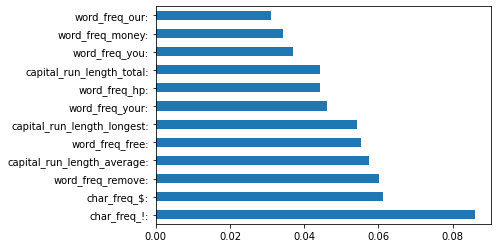

In [ ]:
feat_importances = pd.Series(rf_all.feature_importances_, index=X.columns)
feat_importances.nlargest(12).plot(kind='barh')

---
---

### **Part 15:** 

Lastly, I would like to propose a variable that currently is not in the dataset, which if included, would likely increase my final model's predictive power.

---

---


**Answer:** I believe that adding a variable called ***word_freq_survey***, which is not included in the present data set, would increase my prediction accuracy scores more. The reason is that many spam emails are intended to get recipients to respond to survey questions, including survey questions about customer satisfaction as well as political surveys and surveys about consumer behavior. The variable word_freq_survey would need to measure the percentage of words in a given email that matches the word survey or surveys.

---
